In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from scipy.interpolate import UnivariateSpline
from scipy.interpolate import CubicSpline # 分段三次样条插值方法
from scipy.interpolate import PchipInterpolator # 分段三次 Hermite 插值
from scipy.interpolate import CubicHermiteSpline

matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 指定中文字体
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

### 假设1：GDP数据预测

#### 三次多项式样条插值

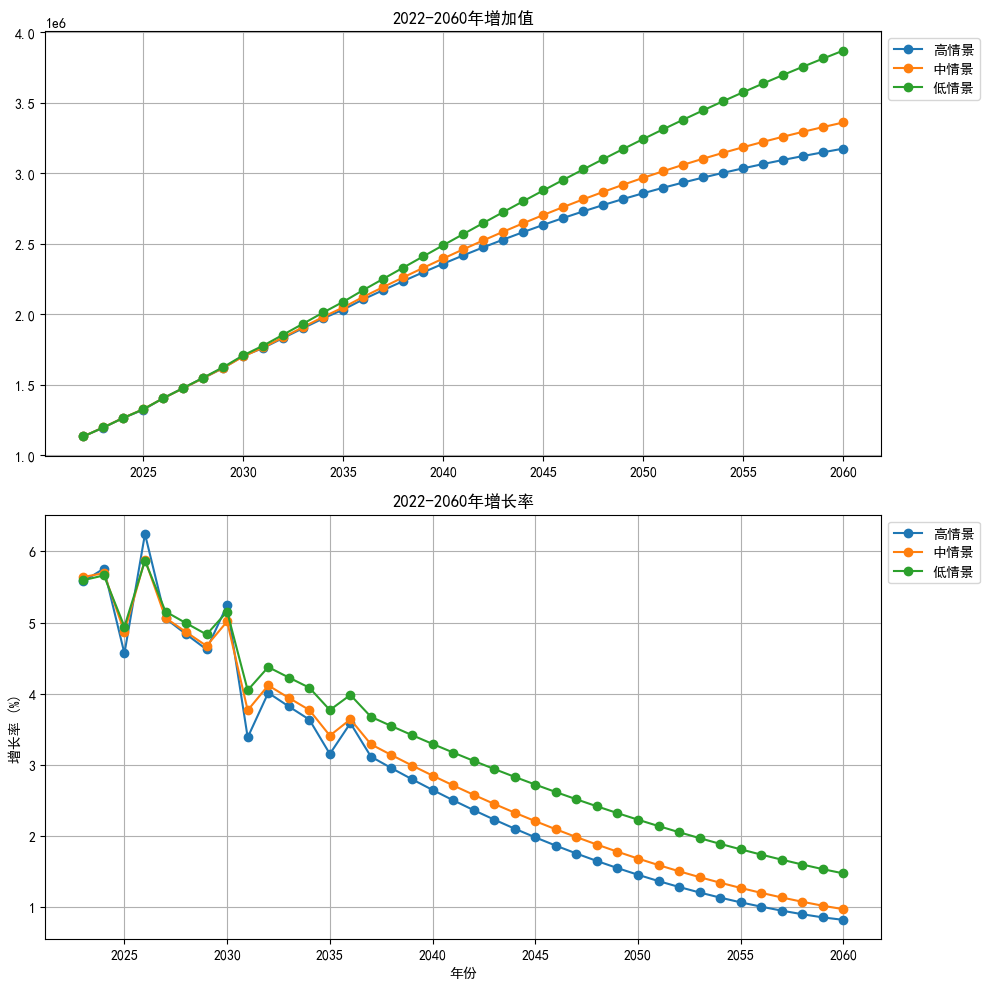

In [2]:
# 数据导入
data = pd.read_excel('./输入/假设1：GDP-2020年不变价.xlsx') 

# 数据处理
index_names = data.iloc[:, 0].values  # 提取索引
data = data.iloc[:, 1:].set_index(index_names) # 重置索引

# 数据筛选
data_stamp = data[[2022, 2025, 2030, 2035, 2060]].dropna(axis=0)  # 保留初始年（2022）、目标年（2025、2030、2035以及2060年数据）


# 数据插值：样条插值
# 设置插值的年份
original_year = list(range(2023, 2061))  # 数据区间
year_to_remove = [2025, 2030, 2035, 2060]
year_to_interpolate = [x for x in original_year if x not in year_to_remove]

# 设置平滑因子
smoothing_factor = 0.1 # 调整平滑程度，平滑因子越大数据之间增长率的变化越小
# 接受预测的GDP数据
data_prediction = pd.DataFrame(index=data_stamp.index, columns=year_to_interpolate, dtype=float)

# 对每一行(行业)进行插值
for industry in data_stamp.index:
    x = data_stamp.columns.astype(int)  # 已知年份
    y = np.log(data_stamp.loc[industry].values)  # 对应行业的对数值
    spline = UnivariateSpline(x, y, k=3, s=smoothing_factor) # 创建样条插值对象
    missing_values = np.exp(spline(year_to_interpolate)) # 计算缺失年份的插值结果
    data_prediction.loc[industry] = missing_values  # 添加到预测值DataFrame中

# 合并预测值DataFrame和原始DataFrame
data_interpolate = pd.concat([data_stamp, data_prediction], axis=1)

# 将列名转换为整数类型并按年份从小到大排序列
data_interpolate.columns = data_interpolate.columns.astype(int)
data_interpolate = data_interpolate.reindex(sorted(data_interpolate.columns), axis=1)


# 图形绘制
data_growth_rate = data_interpolate.pct_change(axis=1) * 100 # 计算增长率

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10)) # 设置画布和子图

# 绘制计算的GDP折线图
for industry in data_interpolate.index:
    ax1.plot(data_interpolate.columns, data_interpolate.loc[industry], marker='o', label=industry)

ax1.set_title('2022-2060年增加值')  # 设置图标题
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))  # 设置图例位置为右上角
ax1.grid(True)  # 显示网格线

# 绘制增长率折线图
for industry in data_growth_rate.index:
    ax2.plot(data_growth_rate.columns, data_growth_rate.loc[industry], marker='o', label=industry)

ax2.set_title('2022-2060年增长率')  # 设置图标题
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))  # 设置图例位置为右上角
ax2.grid(True)  # 显示网格线
ax2.set_xlabel('年份')  # 设置横轴标签
ax2.set_ylabel('增长率 (%)')  # 设置纵轴标签

plt.tight_layout()  # 调整子图布局
plt.show()  # 显示图形

In [4]:
# 导出数据
writer = pd.ExcelWriter('./输出/结果1：GDP数据平滑.xlsx', engine='xlsxwriter') # GDP数据导出
data_interpolate.to_excel(writer, index=True)
writer._save() # 保存Excel文件

### 假设2：农业、工业、建筑业和服务业增加值预测

#### 三次多项式样条插值

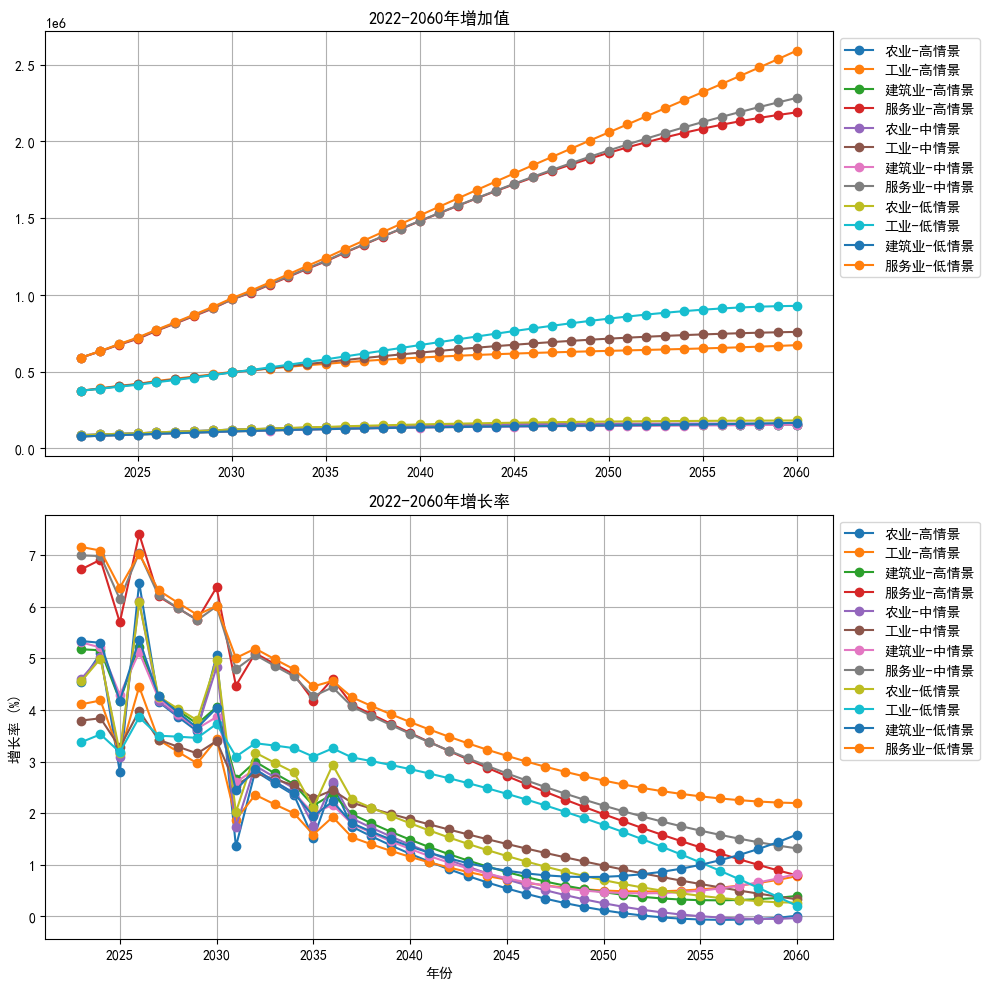

In [20]:
# 数据导入
data = pd.read_excel('./输入/假设2：三次产业结构.xlsx') 

# 数据处理
index_names = data.iloc[:, 0].values  # 提取索引
data = data.iloc[:, 1:].set_index(index_names) # 重置索引

# 数据筛选
data_stamp = data[[2022, 2025, 2030, 2035, 2060]].dropna(axis=0)  # 保留初始年（2022）、目标年（2025、2030、2035以及2060年数据）


# 数据插值：样条插值
# 设置插值的年份
original_year = list(range(2023, 2061))  # 数据区间
year_to_remove = [2025, 2030, 2035, 2060]
year_to_interpolate = [x for x in original_year if x not in year_to_remove]

# 设置平滑因子
smoothing_factor = 1  # 调整平滑程度，平滑因子越大数据之间增长率的变化越小
# 接受预测的GDP数据
data_prediction = pd.DataFrame(index=data_stamp.index, columns=year_to_interpolate, dtype=float)

# 对每一行(行业)进行插值
for industry in data_stamp.index:
    x = data_stamp.columns.astype(int)  # 已知年份
    y = np.log(data_stamp.loc[industry].values)  # 对应行业的对数值
    spline = UnivariateSpline(x, y, k=3, s=smoothing_factor) # 创建样条插值对象
    missing_values = np.exp(spline(year_to_interpolate)) # 计算缺失年份的插值结果
    data_prediction.loc[industry] = missing_values  # 添加到预测值DataFrame中

# 合并预测值DataFrame和原始DataFrame
data_interpolate = pd.concat([data_stamp, data_prediction], axis=1)

# 将列名转换为整数类型并按年份从小到大排序列
data_interpolate.columns = data_interpolate.columns.astype(int)
data_interpolate = data_interpolate.reindex(sorted(data_interpolate.columns), axis=1)


# 图形绘制
data_growth_rate = data_interpolate.pct_change(axis=1) * 100 # 计算增长率

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10)) # 设置画布和子图

# 绘制计算的GDP折线图
for industry in data_interpolate.index:
    ax1.plot(data_interpolate.columns, data_interpolate.loc[industry], marker='o', label=industry)

ax1.set_title('2022-2060年增加值')  # 设置图标题
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))  # 设置图例位置为右上角
ax1.grid(True)  # 显示网格线

# 绘制增长率折线图
for industry in data_growth_rate.index:
    ax2.plot(data_growth_rate.columns, data_growth_rate.loc[industry], marker='o', label=industry)

ax2.set_title('2022-2060年增长率')  # 设置图标题
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))  # 设置图例位置为右上角
ax2.grid(True)  # 显示网格线
ax2.set_xlabel('年份')  # 设置横轴标签
ax2.set_ylabel('增长率 (%)')  # 设置纵轴标签

plt.tight_layout()  # 调整子图布局
plt.show()  # 显示图形

In [22]:
# 导出数据
writer = pd.ExcelWriter('./输出/结果2：三次产业增加值平滑.xlsx', engine='xlsxwriter') # GDP数据导出
data_interpolate.to_excel(writer, index=True)
writer._save() # 保存Excel文件

### 假设3：产业大类数据

#### 分段三次 Hermite 插值

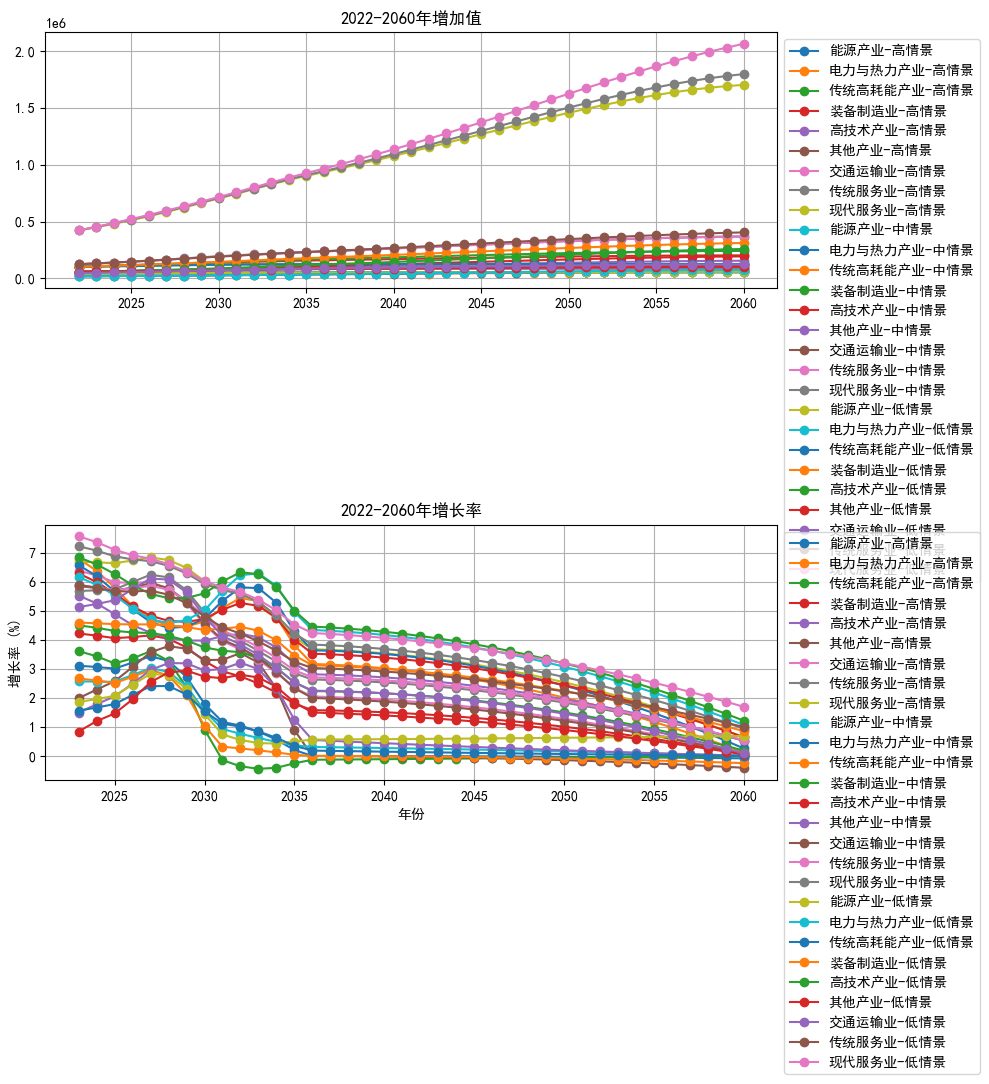

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# 数据导入
data = pd.read_excel('./输入/假设3：产业大类结构.xlsx')

# 数据处理
index_names = data.iloc[:, 0].values
data = data.iloc[:, 1:].set_index(index_names)

# 数据筛选
data_stamp = data[[2022, 2025, 2030, 2035, 2060]].dropna(axis=0)

# 数据插值
original_year = list(range(2023, 2061))
year_to_remove = [2025, 2030, 2035, 2060]
year_to_interpolate = [x for x in original_year if x not in year_to_remove]

data_prediction = pd.DataFrame(index=data_stamp.index, columns=year_to_interpolate, dtype=float)

# 分段三次 Hermite 插值法
for industry in data_stamp.index:
    x = data_stamp.columns.astype(int)
    y = np.log(data_stamp.loc[industry].values)
    
    # 使用分段三次 Hermite 插值
    interp_func = PchipInterpolator(x, y)
    
    missing_values = np.exp(interp_func(year_to_interpolate))
    data_prediction.loc[industry] = missing_values

data_interpolate = pd.concat([data_stamp, data_prediction], axis=1)
data_interpolate.columns = data_interpolate.columns.astype(int)
data_interpolate = data_interpolate.reindex(sorted(data_interpolate.columns), axis=1)

data_growth_rate = data_interpolate.pct_change(axis=1) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# 绘制计算的GDP折线图
for industry in data_interpolate.index:
    ax1.plot(data_interpolate.columns, data_interpolate.loc[industry], marker='o', label=industry)

ax1.set_title('2022-2060年增加值')
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax1.grid(True)

# 绘制增长率折线图
for industry in data_growth_rate.index:
    ax2.plot(data_growth_rate.columns, data_growth_rate.loc[industry], marker='o', label=industry)

ax2.set_title('2022-2060年增长率')
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax2.grid(True)
ax2.set_xlabel('年份')
ax2.set_ylabel('增长率 (%)')

plt.tight_layout()
plt.show()

#### 分段三次 Catmull-Rom 插值

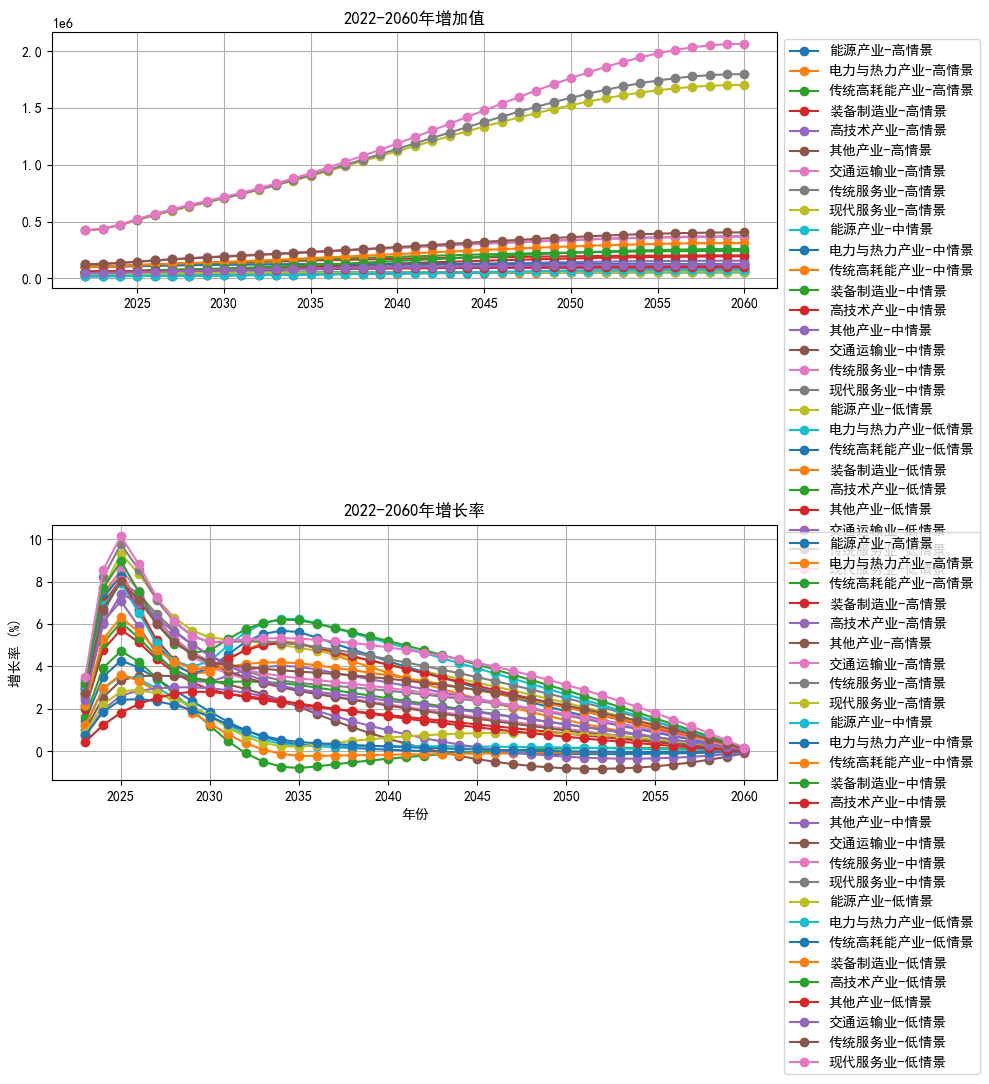

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# 数据导入
data = pd.read_excel('./输入/假设3：产业大类结构.xlsx')

# 数据处理
index_names = data.iloc[:, 0].values
data = data.iloc[:, 1:].set_index(index_names)

# 数据筛选
data_stamp = data[[2022, 2025, 2030, 2035, 2060]].dropna(axis=0)

# 数据插值
original_year = list(range(2023, 2061))
year_to_remove = [2025, 2030, 2035, 2060]
year_to_interpolate = [x for x in original_year if x not in year_to_remove]

data_prediction = pd.DataFrame(index=data_stamp.index, columns=year_to_interpolate, dtype=float)

# 分段三次 Catmull-Rom 插值法
for industry in data_stamp.index:
    x = data_stamp.columns.astype(int)
    y = np.log(data_stamp.loc[industry].values)
    
    # 使用分段三次 Catmull-Rom 插值
    cs = CubicSpline(x, y, bc_type='clamped')
    
    missing_values = np.exp(cs(year_to_interpolate))
    data_prediction.loc[industry] = missing_values

data_interpolate = pd.concat([data_stamp, data_prediction], axis=1)
data_interpolate.columns = data_interpolate.columns.astype(int)
data_interpolate = data_interpolate.reindex(sorted(data_interpolate.columns), axis=1)

data_growth_rate = data_interpolate.pct_change(axis=1) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# 绘制计算的 GDP 折线图
for industry in data_interpolate.index:
    ax1.plot(data_interpolate.columns, data_interpolate.loc[industry], marker='o', label=industry)

ax1.set_title('2022-2060年增加值')
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax1.grid(True)

# 绘制增长率折线图
for industry in data_growth_rate.index:
    ax2.plot(data_growth_rate.columns, data_growth_rate.loc[industry], marker='o', label=industry)

ax2.set_title('2022-2060年增长率')
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax2.grid(True)
ax2.set_xlabel('年份')
ax2.set_ylabel('增长率 (%)')

plt.tight_layout()
plt.show()

In [11]:
# 导出数据
writer = pd.ExcelWriter('./输出/结果3：产业大类增加值平滑.xlsx', engine='xlsxwriter') 
data_interpolate.to_excel(writer, index=True)
writer._save() # 保存Excel文件

### 假设4：细分产业结构

#### 高情景

C:\Users\cjwdl\AppData\Local\Temp\ipykernel_13600\3010275333.py:63: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()  # 调整子图布局


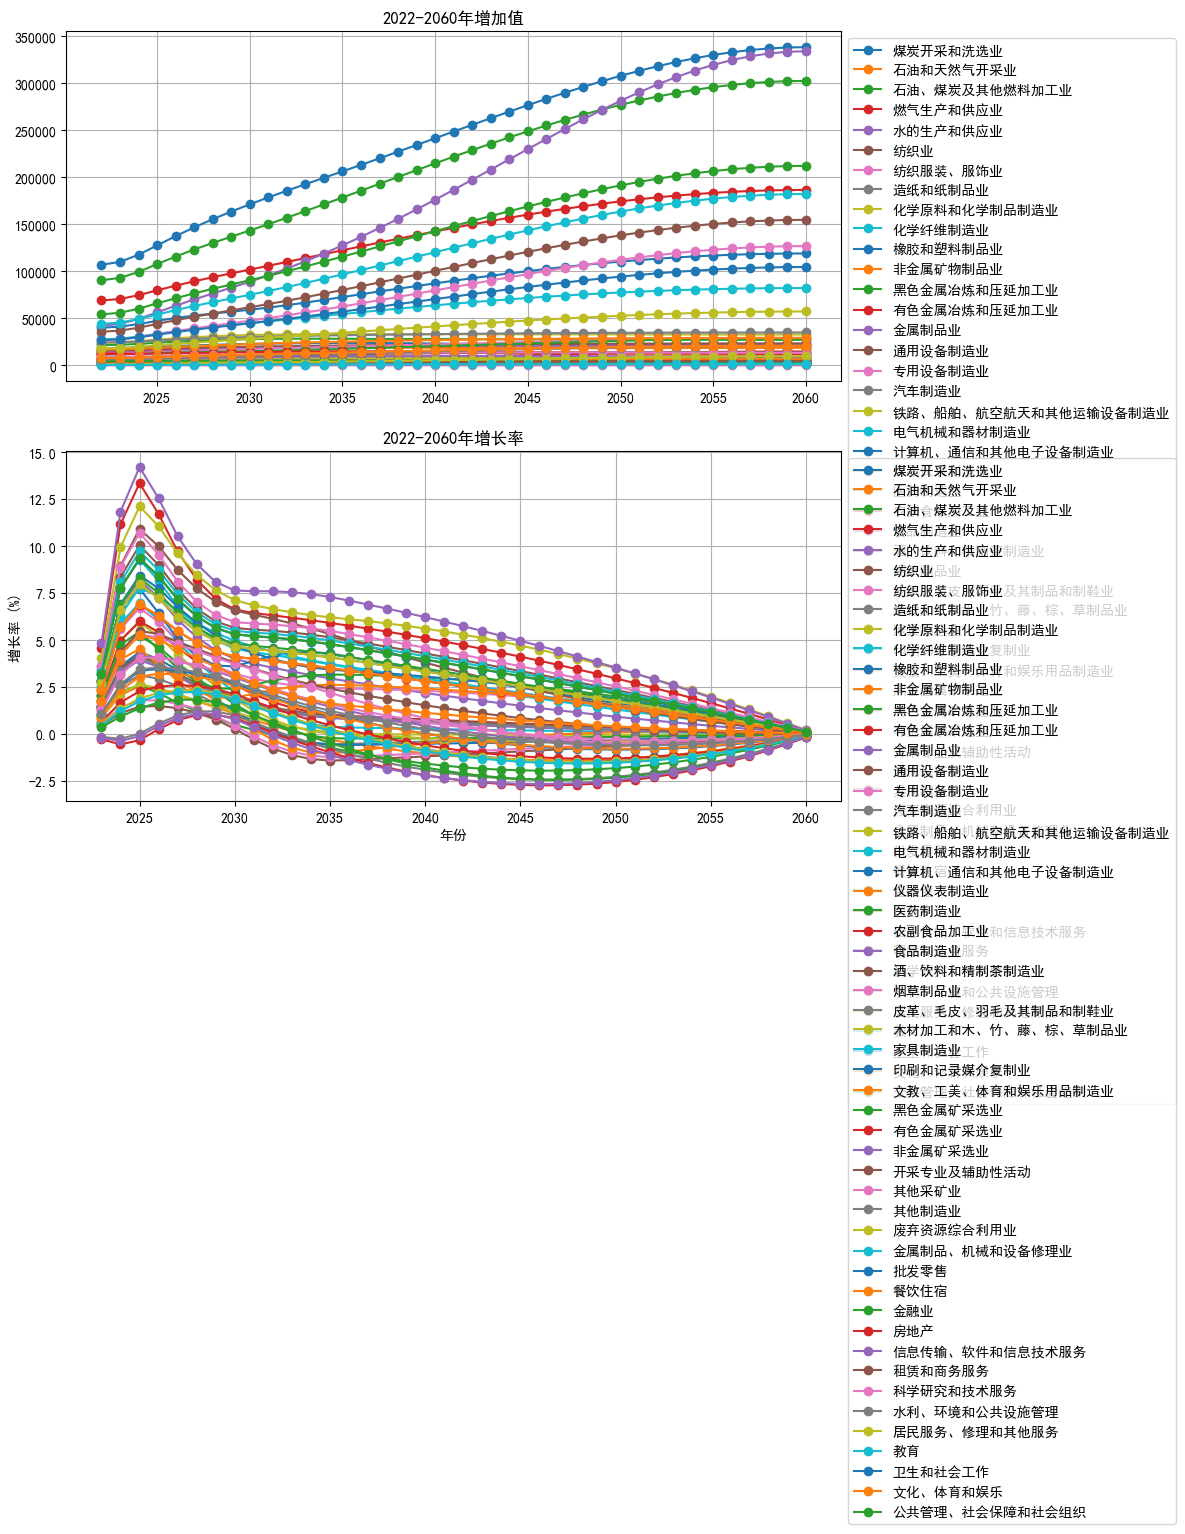

In [20]:
# 数据导入
data = pd.read_excel('./输入/假设4：细分产业结构.xlsx', sheet_name='高情景')

# 数据处理
index_names = data.iloc[:, 0].values  # 提取索引
data = data.iloc[:, 1:].set_index(index_names)  # 重置索引

# 数据筛选
data_stamp = data[[2022, 2025, 2030, 2035, 2060]].dropna(axis=0)  # 保留初始年（2022）、目标年（2025、2030、2035以及2060年数据）

# 数据插值：分段三次样条插值
# 设置插值的年份
original_year = list(range(2023, 2061))  # 数据区间
year_to_remove = [2025, 2030, 2035, 2060]
year_to_interpolate = [x for x in original_year if x not in year_to_remove]

# 设置平滑因子
smoothing_factor = 0.8  # 调整平滑程度，平滑因子越大数据之间增长率的变化越小
# 接受预测的GDP数据
data_prediction = pd.DataFrame(index=data_stamp.index, columns=year_to_interpolate, dtype=float)

# 对每一行(行业)进行插值
# 分段三次 Catmull-Rom 插值法
for industry in data_stamp.index:
    x = data_stamp.columns.astype(int)
    y = np.log(data_stamp.loc[industry].values)   
    # 使用分段三次 Catmull-Rom 插值
    cs = CubicSpline(x, y, bc_type='clamped')
    missing_values = np.exp(cs(year_to_interpolate))
    data_prediction.loc[industry] = missing_values

# 合并预测值DataFrame和原始DataFrame
data_interpolate = pd.concat([data_stamp, data_prediction], axis=1)

# 将列名转换为整数类型并按年份从小到大排序列
data_interpolate.columns = data_interpolate.columns.astype(int)
data_interpolate = data_interpolate.reindex(sorted(data_interpolate.columns), axis=1)


# 图形绘制
data_growth_rate = data_interpolate.pct_change(axis=1) * 100 # 计算增长率

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10)) # 设置画布和子图

# 绘制计算的GDP折线图
for industry in data_interpolate.index:
    ax1.plot(data_interpolate.columns, data_interpolate.loc[industry], marker='o', label=industry)

ax1.set_title('2022-2060年增加值')  # 设置图标题
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))  # 设置图例位置为右上角
ax1.grid(True)  # 显示网格线

# 绘制增长率折线图
for industry in data_growth_rate.index:
    ax2.plot(data_growth_rate.columns, data_growth_rate.loc[industry], marker='o', label=industry)

ax2.set_title('2022-2060年增长率')  # 设置图标题
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))  # 设置图例位置为右上角
ax2.grid(True)  # 显示网格线
ax2.set_xlabel('年份')  # 设置横轴标签
ax2.set_ylabel('增长率 (%)')  # 设置纵轴标签

plt.tight_layout()  # 调整子图布局
plt.show()  # 显示图形

In [21]:
# 导出数据
writer = pd.ExcelWriter('./输出/结果4-1：高情景细分产业增加值平滑.xlsx', engine='xlsxwriter') 
data_interpolate.to_excel(writer, index=True)
writer._save() # 保存Excel文件

#### 低情景

C:\Users\cjwdl\AppData\Local\Temp\ipykernel_13600\1611896087.py:71: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()  # 调整子图布局


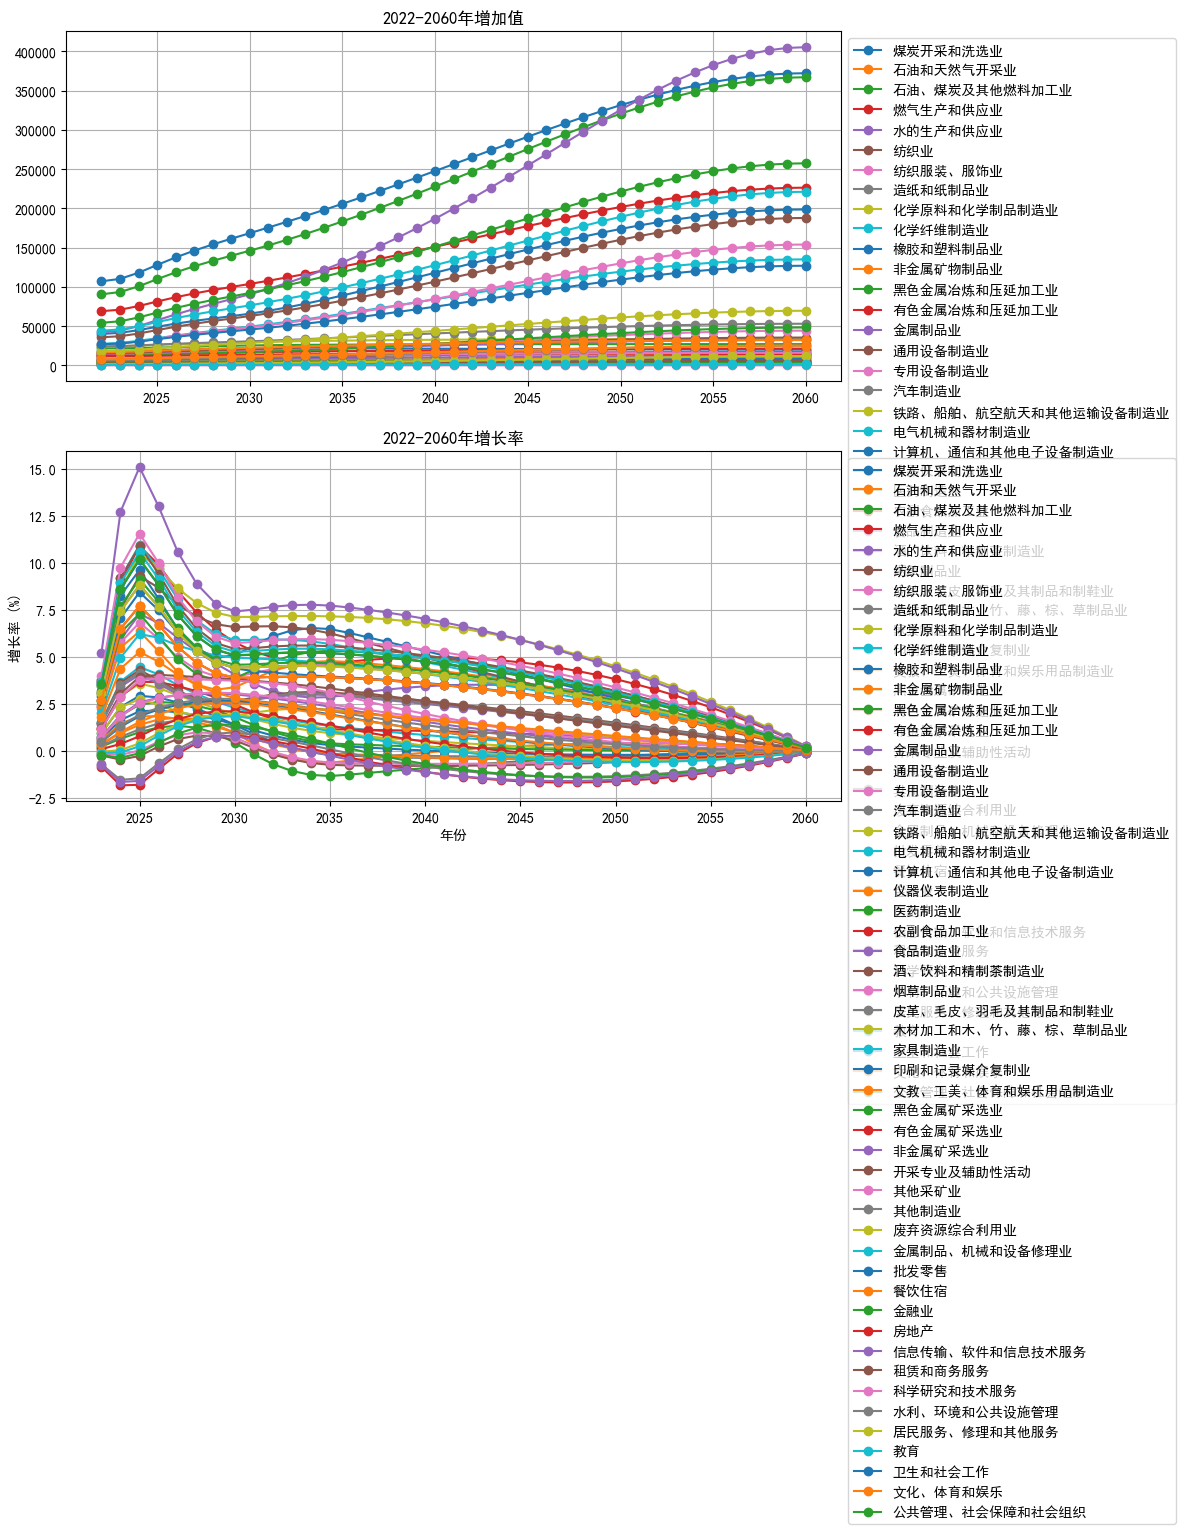

In [16]:
# 数据导入
data = pd.read_excel('./输入/假设4：细分产业结构.xlsx', sheet_name='低情景')

# 数据处理
index_names = data.iloc[:, 0].values  # 提取索引
data = data.iloc[:, 1:].set_index(index_names)  # 重置索引

# 数据筛选
data_stamp = data[[2022, 2025, 2030, 2035, 2060]].dropna(axis=0)  # 保留初始年（2022）、目标年（2025、2030、2035以及2060年数据）

# 数据插值：分段三次样条插值
# 设置插值的年份
original_year = list(range(2023, 2061))  # 数据区间
year_to_remove = [2025, 2030, 2035, 2060]
year_to_interpolate = [x for x in original_year if x not in year_to_remove]

# 设置平滑因子
smoothing_factor = 0.8  # 调整平滑程度，平滑因子越大数据之间增长率的变化越小
# 接受预测的GDP数据
data_prediction = pd.DataFrame(index=data_stamp.index, columns=year_to_interpolate, dtype=float)

# 分段三次 Catmull-Rom 插值法
for industry in data_stamp.index:
    x = data_stamp.columns.astype(int)
    y = np.log(data_stamp.loc[industry].values)   
    # 使用分段三次 Catmull-Rom 插值
    cs = CubicSpline(x, y, bc_type='clamped')
    missing_values = np.exp(cs(year_to_interpolate))
    data_prediction.loc[industry] = missing_values

# # 分段三次 Hermite 插值法
# for industry in data_stamp.index:
#     x = data_stamp.columns.astype(int)
#     y = np.log(data_stamp.loc[industry].values)
#     # 使用分段三次 Hermite 插值
#     interp_func = PchipInterpolator(x, y) 
#     missing_values = np.exp(interp_func(year_to_interpolate))
#     data_prediction.loc[industry] = missing_values

# 合并预测值DataFrame和原始DataFrame
data_interpolate = pd.concat([data_stamp, data_prediction], axis=1)

# 将列名转换为整数类型并按年份从小到大排序列
data_interpolate.columns = data_interpolate.columns.astype(int)
data_interpolate = data_interpolate.reindex(sorted(data_interpolate.columns), axis=1)


# 图形绘制
data_growth_rate = data_interpolate.pct_change(axis=1) * 100 # 计算增长率

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10)) # 设置画布和子图

# 绘制计算的GDP折线图
for industry in data_interpolate.index:
    ax1.plot(data_interpolate.columns, data_interpolate.loc[industry], marker='o', label=industry)

ax1.set_title('2022-2060年增加值')  # 设置图标题
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))  # 设置图例位置为右上角
ax1.grid(True)  # 显示网格线

# 绘制增长率折线图
for industry in data_growth_rate.index:
    ax2.plot(data_growth_rate.columns, data_growth_rate.loc[industry], marker='o', label=industry)

ax2.set_title('2022-2060年增长率')  # 设置图标题
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))  # 设置图例位置为右上角
ax2.grid(True)  # 显示网格线
ax2.set_xlabel('年份')  # 设置横轴标签
ax2.set_ylabel('增长率 (%)')  # 设置纵轴标签

plt.tight_layout()  # 调整子图布局
plt.show()  # 显示图形

In [17]:
# 导出数据
writer = pd.ExcelWriter('./输出/结果4-2：低情景细分产业增加值平滑.xlsx', engine='xlsxwriter') 
data_interpolate.to_excel(writer, index=True)
writer._save() # 保存Excel文件

#### 中情景

C:\Users\cjwdl\AppData\Local\Temp\ipykernel_13600\2775587469.py:62: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()  # 调整子图布局


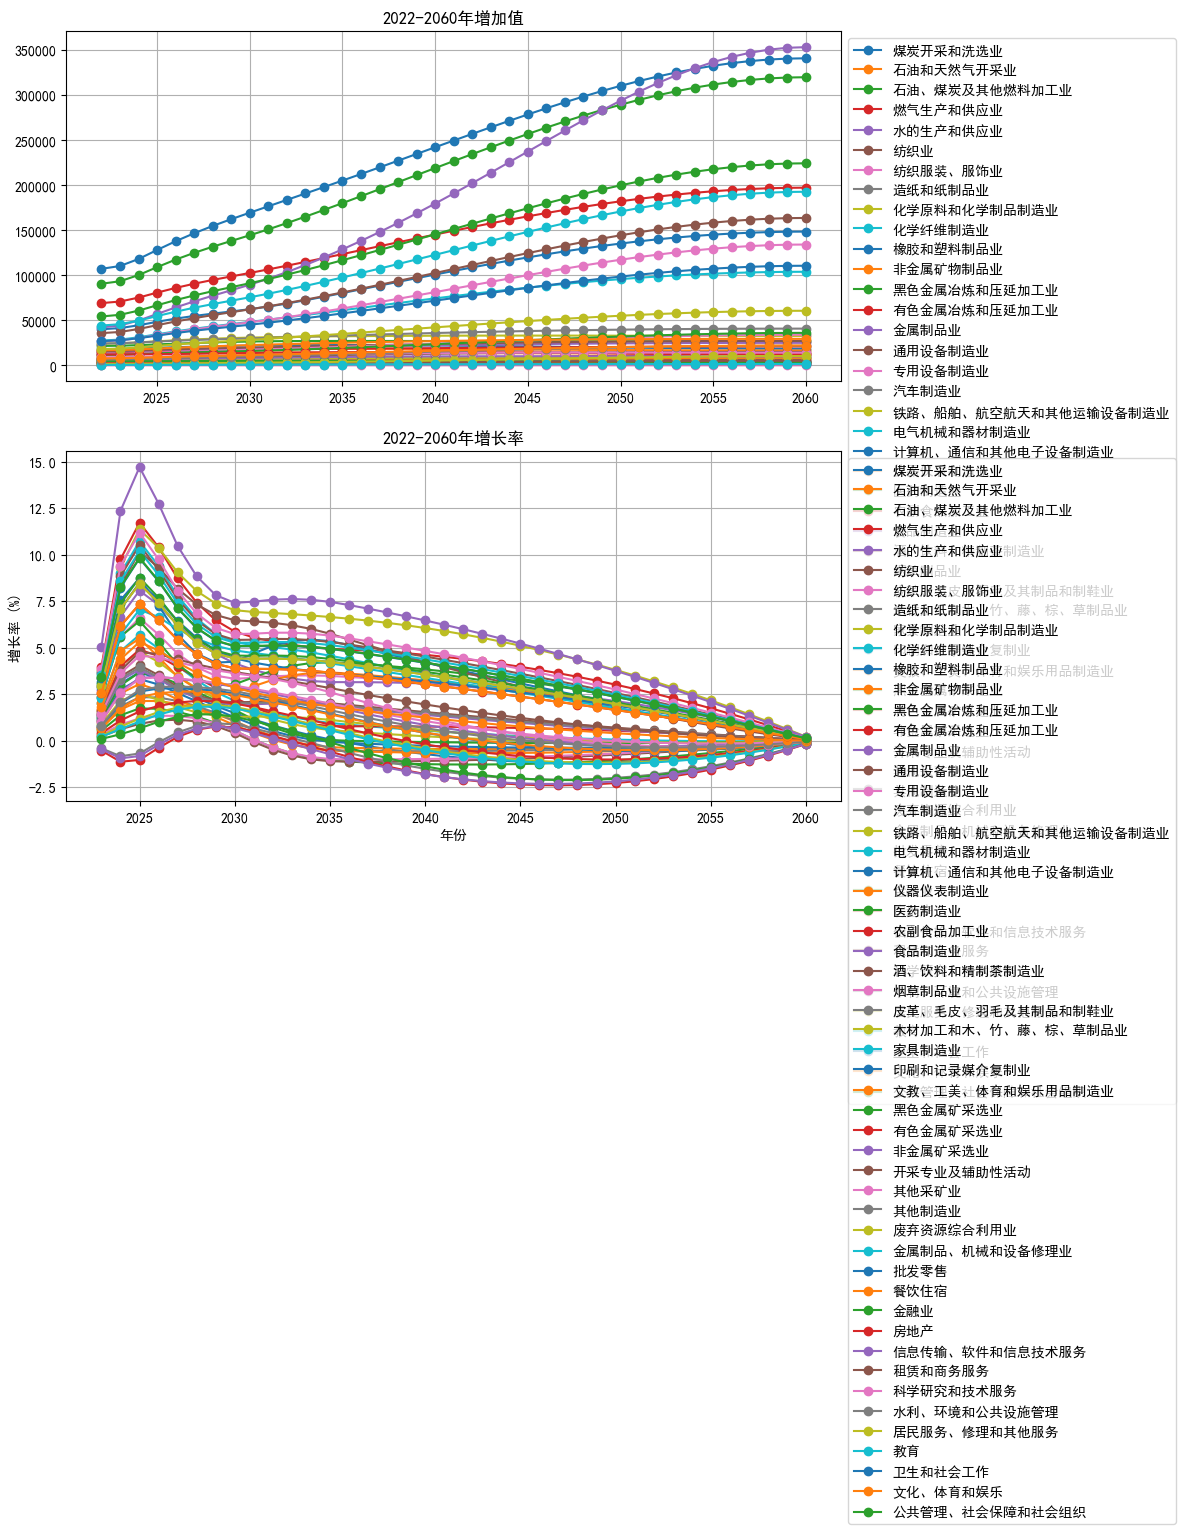

In [18]:
# 数据导入
data = pd.read_excel('./输入/假设4：细分产业结构.xlsx', sheet_name='中情景')

# 数据处理
index_names = data.iloc[:, 0].values  # 提取索引
data = data.iloc[:, 1:].set_index(index_names)  # 重置索引

# 数据筛选
data_stamp = data[[2022, 2025, 2030, 2035, 2060]].dropna(axis=0)  # 保留初始年（2022）、目标年（2025、2030、2035以及2060年数据）

# 数据插值：分段三次样条插值
# 设置插值的年份
original_year = list(range(2023, 2061))  # 数据区间
year_to_remove = [2025, 2030, 2035, 2060]
year_to_interpolate = [x for x in original_year if x not in year_to_remove]

# 设置平滑因子
smoothing_factor = 0.8  # 调整平滑程度，平滑因子越大数据之间增长率的变化越小
# 接受预测的GDP数据
data_prediction = pd.DataFrame(index=data_stamp.index, columns=year_to_interpolate, dtype=float)

# 分段三次 Catmull-Rom 插值法
for industry in data_stamp.index:
    x = data_stamp.columns.astype(int)
    y = np.log(data_stamp.loc[industry].values)   
    # 使用分段三次 Catmull-Rom 插值
    cs = CubicSpline(x, y, bc_type='clamped')
    missing_values = np.exp(cs(year_to_interpolate))
    data_prediction.loc[industry] = missing_values

# 合并预测值DataFrame和原始DataFrame
data_interpolate = pd.concat([data_stamp, data_prediction], axis=1)

# 将列名转换为整数类型并按年份从小到大排序列
data_interpolate.columns = data_interpolate.columns.astype(int)
data_interpolate = data_interpolate.reindex(sorted(data_interpolate.columns), axis=1)


# 图形绘制
data_growth_rate = data_interpolate.pct_change(axis=1) * 100 # 计算增长率

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10)) # 设置画布和子图

# 绘制计算的GDP折线图
for industry in data_interpolate.index:
    ax1.plot(data_interpolate.columns, data_interpolate.loc[industry], marker='o', label=industry)

ax1.set_title('2022-2060年增加值')  # 设置图标题
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))  # 设置图例位置为右上角
ax1.grid(True)  # 显示网格线

# 绘制增长率折线图
for industry in data_growth_rate.index:
    ax2.plot(data_growth_rate.columns, data_growth_rate.loc[industry], marker='o', label=industry)

ax2.set_title('2022-2060年增长率')  # 设置图标题
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))  # 设置图例位置为右上角
ax2.grid(True)  # 显示网格线
ax2.set_xlabel('年份')  # 设置横轴标签
ax2.set_ylabel('增长率 (%)')  # 设置纵轴标签

plt.tight_layout()  # 调整子图布局
plt.show()  # 显示图形

In [19]:
# 导出数据
writer = pd.ExcelWriter('./输出/结果4-3：中情景细分产业增加值平滑.xlsx', engine='xlsxwriter') 
data_interpolate.to_excel(writer, index=True)
writer._save() # 保存Excel文件